In [1]:
import sccellfie
import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


import glasbey

import textwrap

## To avoid warnings
import warnings
warnings.filterwarnings("ignore")

/home/kvalem/.conda/envs/sccellfie/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/kvalem/.conda/envs/sccellfie/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
import anndata as ad

In [3]:
sc.settings.figdir = '/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/da-figures/'

In [4]:
adata = sccellfie.io.load_adata(folder='/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie',
                                filename='Honda_tumor_scCellFie_without_cycling_effector'
                               )

/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/Honda_tumor_scCellFie_without_cycling_effector.h5ad was correctly loaded
/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/Honda_tumor_scCellFie_without_cycling_effector_reactions.h5ad was correctly loaded
/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/Honda_tumor_scCellFie_without_cycling_effector_metabolic_tasks.h5ad was correctly loaded


In [5]:
adata

AnnData object with n_obs × n_vars = 18389 × 683
    obs: 'sample_id', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'adata_name', 'condition', 'batch_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05', 'n_counts'
    var: 'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells', 'gene_count_corr'
    uns: 'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'l

In [6]:
adata.metabolic_tasks

AnnData object with n_obs × n_vars = 18389 × 185
    obs: 'sample_id', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'adata_name', 'condition', 'batch_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05', 'n_counts'
    uns: 'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'normalization', 'pca', 'rna_leiden', 'rna_leiden_05', 'rna_leiden_05_colors', 'rna_leiden_colors', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

## Defining cell types

In [7]:
cell_group = 'cell_annotation_05'

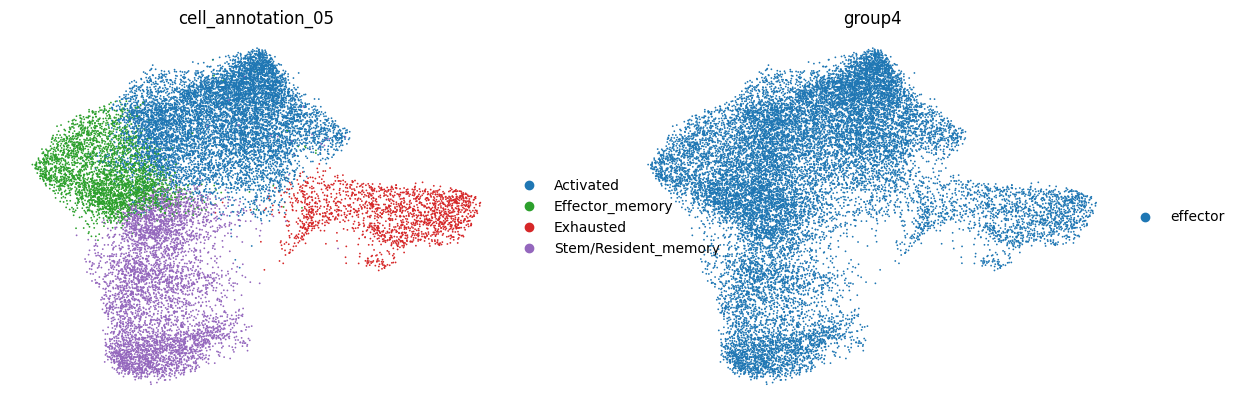

In [8]:
sc.pl.umap(adata, color=[cell_group,"group4"],frameon=False)

In [9]:
adata.metabolic_tasks.obs

,sample_id,batch,initial_size_unspliced,initial_size_spliced,initial_size,adata_name,condition,batch_id,n_genes_by_counts,log1p_n_genes_by_counts,...,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,rna_leiden,rna_leiden_05,gex03,group4,cell_annotation_05,n_counts
11mix-ICI1_AAACCTGGTGCCTTGG-1,2021_11mix-ICI1,2021_11mix-ICI1,482.0,337.0,337.0,adata_11mix_ICI1,11mix,ICI1,3318,8.107419,...,0.0,0.0,0.0,0.0,0,0,0,effector,Activated,181.000031
11mix-ICI1_AAACCTGGTACCGTAT-1,2021_11mix-ICI1,2021_11mix-ICI1,432.0,248.0,248.0,adata_11mix_ICI1,11mix,ICI1,2811,7.941651,...,0.0,0.0,0.0,0.0,0,0,0,effector,Activated,180.270157
11mix-ICI1_AAAGATGTCGTAGATC-1,2021_11mix-ICI1,2021_11mix-ICI1,268.0,222.0,222.0,adata_11mix_ICI1,11mix,ICI1,2501,7.824846,...,0.0,0.0,0.0,0.0,0,0,0,effector,Activated,181.000015
11mix-ICI1_AAACCTGTCTTAGAGC-1,2021_11mix-ICI1,2021_11mix-ICI1,279.0,237.0,237.0,adata_11mix_ICI1,11mix,ICI1,2206,7.699389,...,0.0,0.0,0.0,0.0,0,0,0,effector,Activated,180.236282
11mix-ICI1_AAAGTAGTCCTCGCAT-1,2021_11mix-ICI1,2021_11mix-ICI1,177.0,77.0,77.0,adata_11mix_ICI1,11mix,ICI1,1476,7.297768,...,0.0,0.0,0.0,0.0,6,0,0,effector,Activated,180.999969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11mix-ICI2_TTTCCTCTCCACGACG-1,2021_11mix-ICI2,2021_11mix-ICI2,189.0,470.0,470.0,adata_11mix_ICI2,11mix,ICI2,1292,7.164720,...,0.0,0.0,0.0,0.0,2,3,1,effector,Stem/Resident_memory,180.999924
11mix-ICI2_TTTGCGCGTGATAAGT-1,2021_11mix-ICI2,2021_11mix-ICI2,229.0,104.0,104.0,adata_11mix_ICI2,11mix,ICI2,1816,7.504942,...,0.0,0.0,0.0,0.0,6,0,0,effector,Activated,181.000031
11mix-ICI2_TTTATGCCAACACGCC-1,2021_11mix-ICI2,2021_11mix-ICI2,332.0,194.0,194.0,adata_11mix_ICI2,11mix,ICI2,2524,7.833996,...,0.0,0.0,0.0,0.0,0,0,0,effector,Activated,181.000000
11mix-ICI2_TTTGCGCTCTCACATT-1,2021_11mix-ICI2,2021_11mix-ICI2,435.0,231.0,231.0,adata_11mix_ICI2,11mix,ICI2,2820,7.944847,...,0.0,0.0,0.0,0.0,6,0,0,effector,Activated,180.999985


## Identification of metabolic markers

## Detection using TF-IDF

In [10]:
mrks = sccellfie.external.quick_markers(adata.metabolic_tasks,
                                        cluster_key=cell_group,
                                        n_markers=20,
                                        express_cut=5*np.log(2))

<Axes: >

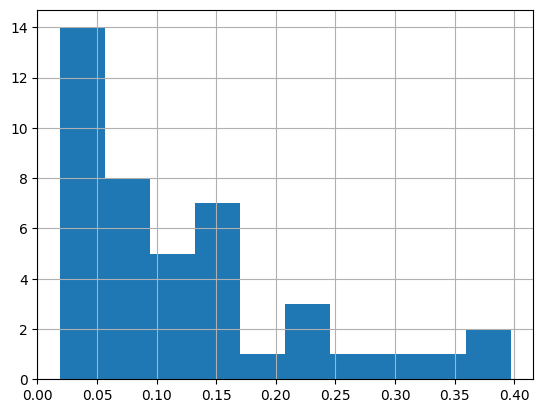

In [11]:
# Visualize TF-IDF score distribution
mrks['tf_idf'].hist()

Text(0, 0.5, 'IDF')

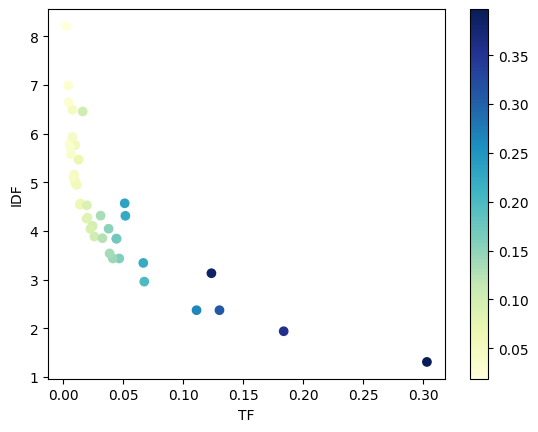

In [12]:
# Scatter plot of TF vs IDF with TF-IDF as color
scatter = plt.scatter(mrks['tf'], mrks['idf'], c=mrks['tf_idf'], cmap='YlGnBu')
plt.colorbar(scatter)
plt.xlabel('TF')
plt.ylabel('IDF')

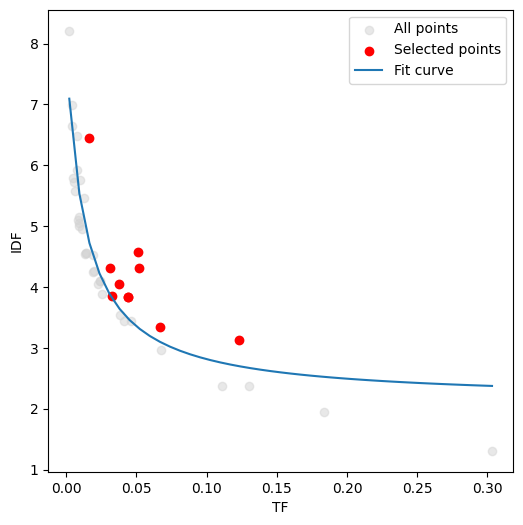

In [13]:
x_col = 'tf'
y_col = 'idf'
df = mrks
tfidf_threshold = 0.1
tf_ratio = 1.2

# Visualization
plt.figure(figsize=(6, 6))
# Plot all points
plt.scatter(df[x_col], df[y_col], alpha=0.5, c='lightgray', label='All points')
# Plot selected points
filtered_mrks, curve = sccellfie.external.filter_tfidf_markers(df, tf_col=x_col, idf_col=y_col,
                                                              tfidf_threshold=tfidf_threshold,
                                                              tf_ratio=tf_ratio)
plt.scatter(filtered_mrks[x_col], filtered_mrks[y_col], c='red', label='Selected points')
plt.plot(*curve, label='Fit curve')
plt.xlabel('TF')
plt.ylabel('IDF')
plt.legend()

In [14]:
# Get unique list of filtered markers
tf_idf_mrks = filtered_mrks['gene'].unique().tolist()
len(tf_idf_mrks)

10

## Logistic regression

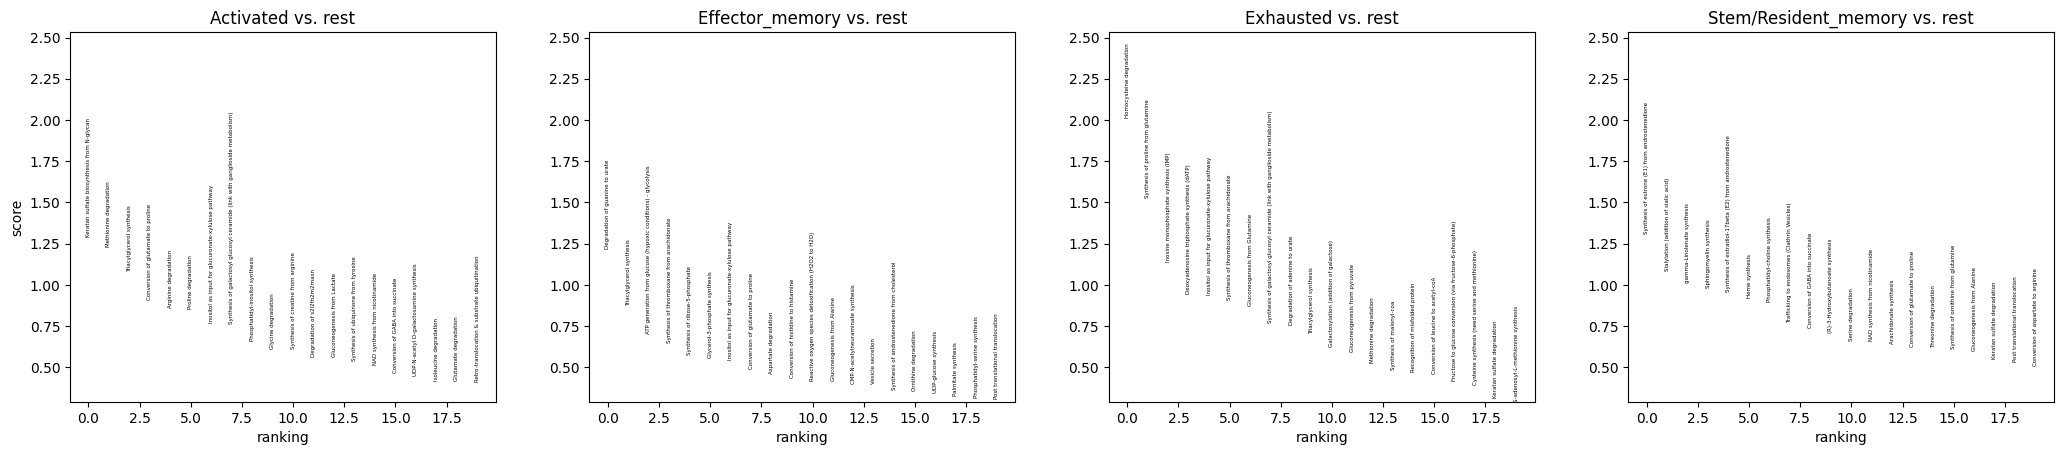

In [15]:
method = 'logreg'
sc.tl.rank_genes_groups(adata.metabolic_tasks, cell_group, method=method,
                       use_raw=False, key_added=method)
sc.pl.rank_genes_groups(adata.metabolic_tasks, n_genes=20, sharey=True, key=method, fontsize=4)

In [16]:
# Get the results as a dataframe
scanpy_df = sc.get.rank_genes_groups_df(adata.metabolic_tasks,
                                      key=method,
                                      group=None)

In [17]:
scanpy_df

,group,names,scores
0,Activated,Keratan sulfate biosynthesis from N-glycan,1.291421
1,Activated,Methionine degradation,1.230615
2,Activated,Triacylglycerol synthesis,1.076913
3,Activated,Conversion of glutamate to proline,0.911787
4,Activated,Arginine degradation,0.864026
...,...,...,...
735,Stem/Resident_memory,Synthesis of proline from glutamine,-1.179342
736,Stem/Resident_memory,Keratan sulfate biosynthesis from N-glycan,-1.432424
737,Stem/Resident_memory,Synthesis of galactosyl glucosyl ceramide (lin...,-1.539578
738,Stem/Resident_memory,Inositol as input for glucuronate-xylulose pat...,-2.251788


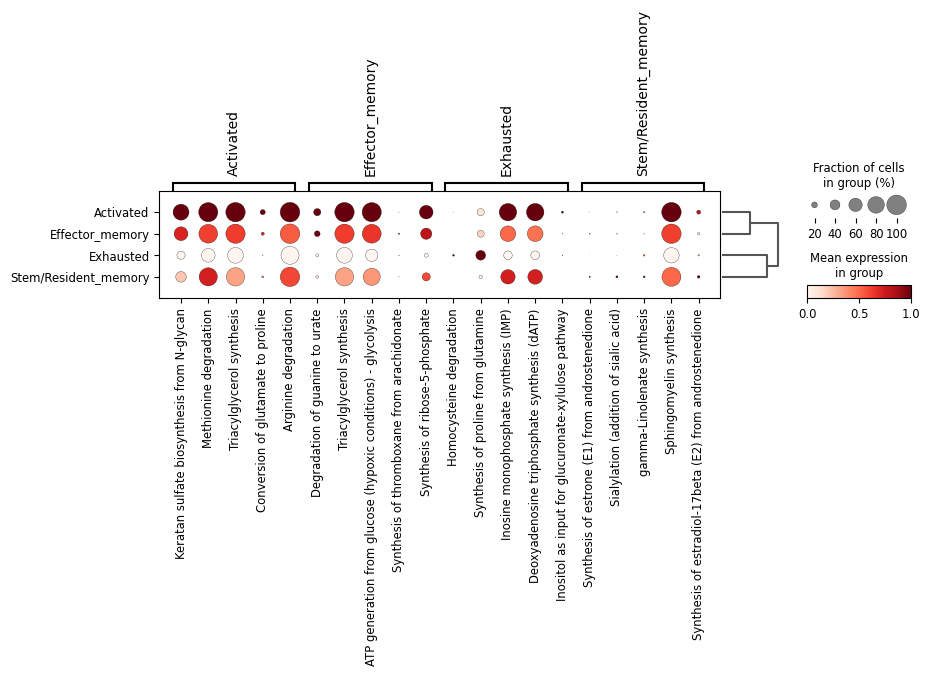

In [18]:
sc.pl.rank_genes_groups_dotplot(adata.metabolic_tasks, n_genes=5, groupby=cell_group,
                               key=method, use_raw=False, standard_scale='var',
                              )

<Axes: >

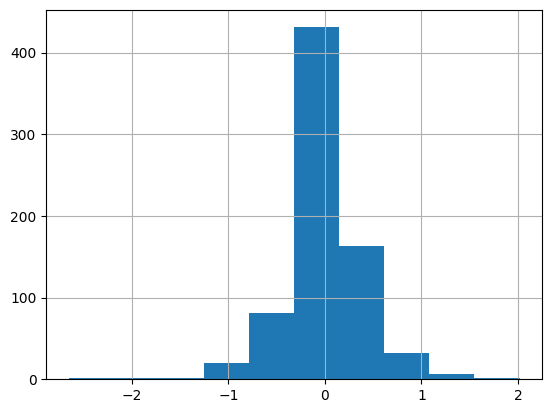

In [19]:
scanpy_df['scores'].hist()

In [20]:
# Filter based on score threshold
scores_threshold = 0.5
filtered_scanpy_mrks = scanpy_df.loc[scanpy_df['scores'] > scores_threshold]

In [21]:
filtered_scanpy_mrks

,group,names,scores
0,Activated,Keratan sulfate biosynthesis from N-glycan,1.291421
1,Activated,Methionine degradation,1.230615
2,Activated,Triacylglycerol synthesis,1.076913
3,Activated,Conversion of glutamate to proline,0.911787
4,Activated,Arginine degradation,0.864026
5,Activated,Proline degradation,0.857151
6,Activated,Inositol as input for glucuronate-xylulose pat...,0.772048
7,Activated,Synthesis of galactosyl glucosyl ceramide (lin...,0.761752
8,Activated,Phosphatidyl-inositol synthesis,0.659538
9,Activated,Glycine degradation,0.615245


In [22]:
# Convert them to a list
scanpy_mrks = filtered_scanpy_mrks['names'].unique().tolist()
len(scanpy_mrks)

46

## Visualization

In [23]:
both_markers = sorted(set(tf_idf_mrks + scanpy_mrks))
len(both_markers)

53

In [24]:
# Aggregate the metabolic activity of markers into a cell-type level using trimean
agg = sccellfie.expression.aggregation.agg_expression_cells(adata.metabolic_tasks[:, both_markers],
                                                            groupby=cell_group,
                                                            agg_func='trimean')

In [25]:
agg

Task,(R)-3-Hydroxybutanoate synthesis,ATP generation from glucose (hypoxic conditions) - glycolysis,Arachidonate synthesis,Arginine degradation,Conversion of GABA into succinate,Conversion of aspartate to arginine,Conversion of glutamate to glutamine,Conversion of glutamate to proline,Conversion of glycine to pyruvate,Degradation of adenine to urate,...,Synthesis of ribose-5-phosphate,Synthesis of thromboxane from arachidonate,Synthesis of ubiquinone from tyrosine,Tetrahydrofolate synthesis,Threonine degradation,Trafficking to endosomes (Clathrin Vesicles),Triacylglycerol synthesis,UDP-glucose synthesis,UDP-glucuronate synthesis,gamma-Linolenate synthesis
Activated,0.621009,0.882933,0.480422,0.353892,0.0,0.0,0.0,0.0,0.0,0.028495,...,0.160326,0.0,0.0,0.264187,0.354929,0.022898,0.308066,0.381954,0.295713,0.0
Effector_memory,0.475413,0.680117,0.403661,0.283836,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.087357,0.0,0.0,0.223300,0.310507,0.014584,0.251208,0.293833,0.231013,0.0
Exhausted,0.197846,0.272154,0.215348,0.201890,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.158547,0.000000,0.138827,0.397898,0.314209,0.0
Stem/Resident_memory,0.375889,0.507076,0.405350,0.291428,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.048074,0.0,0.0,0.000000,0.321076,0.000000,0.202462,0.032597,0.030178,0.0


In [43]:
both_markers = agg.T.loc[(agg.T > 0.5).any(axis=1)].index.tolist()
len(both_markers)

2

In [44]:
both_markers

['(R)-3-Hydroxybutanoate synthesis',
 'ATP generation from glucose (hypoxic conditions) - glycolysis']

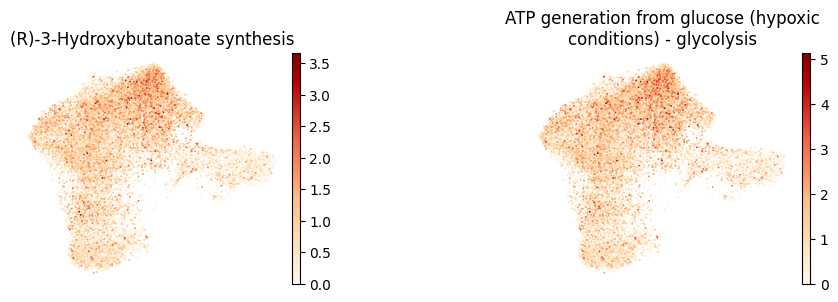

In [45]:
plt.rcParams['figure.figsize'] = (3,3)
plt.rcParams['font.size'] = 10

sc.pl.embedding(adata.metabolic_tasks,
               color=both_markers,
               ncols=4,
               #palette=palette,
               frameon=False,
               basis='X_umap',
               wspace=0.7,
               title=["\n".join(textwrap.wrap(t, width=45)) for t in both_markers],
               cmap='OrRd'
              )

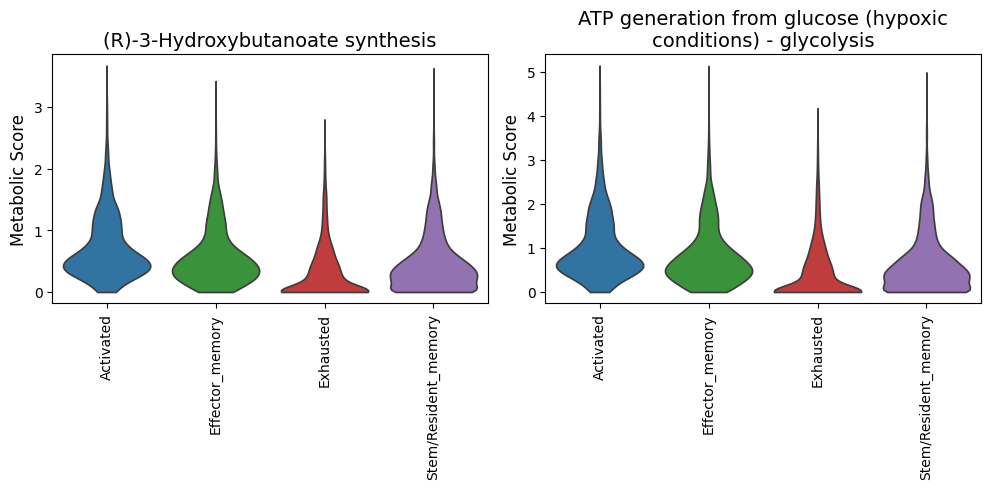

In [46]:
fig, axes = sccellfie.plotting.create_multi_violin_plots(adata.metabolic_tasks,
                                                       features=both_markers,
                                                       groupby=cell_group,
                                                       stripplot=False,
                                                       n_cols=4,
                                                       ylabel='Metabolic Score'
                                                      )

In [47]:
filtered_agg = agg[both_markers]

In [48]:
filtered_agg.head()

Task,(R)-3-Hydroxybutanoate synthesis,ATP generation from glucose (hypoxic conditions) - glycolysis
Activated,0.621009,0.882933
Effector_memory,0.475413,0.680117
Exhausted,0.197846,0.272154
Stem/Resident_memory,0.375889,0.507076


In [49]:
normalized_markers = sccellfie.preprocessing.min_max_normalization(filtered_agg, axis=0)

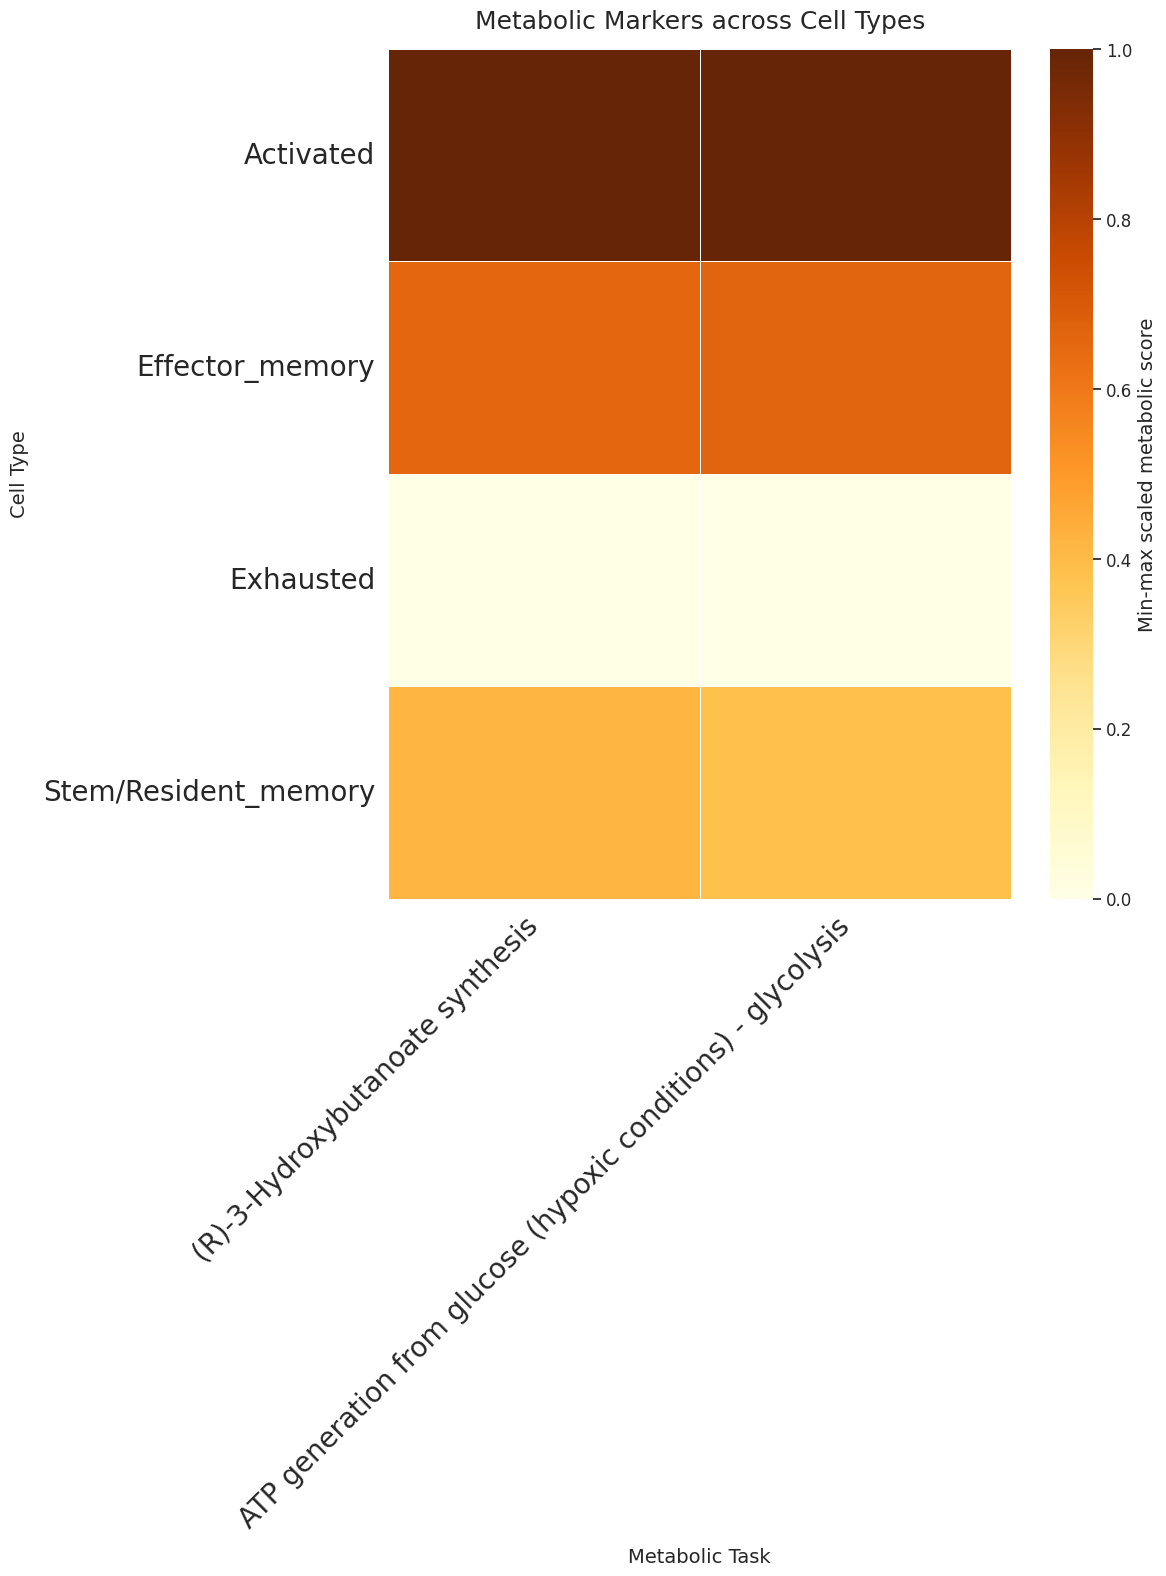

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Option 1: Adjust global font scale for Seaborn (scales everything at once)
sns.set_theme(font_scale=1.2)  # Try 1.2, 1.5, or 2.0 to scale up overall text

# Create figure
plt.figure(figsize=(12, 16))  # Slightly increased figure size for larger labels

# Create heatmap
ax = sns.heatmap(
    normalized_markers,
    cmap="YlOrBr",
    annot=False,
    linewidths=0.5,
    cbar_kws={
        "label": "Min-max scaled metabolic score",
    },
)

# Option 2: Fine-tune individual font sizes
plt.title(
    "Metabolic Markers across Cell Types", fontsize=18, pad=15
)  # Heatmap title
plt.ylabel("Cell Type", fontsize=14, labelpad=10)  # Y-axis label
plt.xlabel("Metabolic Task", fontsize=14, labelpad=10)  # X-axis label

# Increase tick label font sizes (cell type and task names)
plt.xticks(fontsize=20, rotation=45, ha="right")
plt.yticks(fontsize=20, rotation=0)

# Increase colorbar label and tick font size
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_size(14)  # Colorbar title/label size
cbar.ax.tick_params(labelsize=12)  # Colorbar numbers size

plt.tight_layout()
plt.savefig("metabolic_markers_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()